# Gaussian test

In [15]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import random
import time
import networkx as nx
import matplotlib.pyplot as plt
import sys
sys.path.append("../")

from src.exp3 import train_exp3
from src.bandits import OSE4, train_bandit
from src.baseline_models import train_knn, train_perceptron, train_rst
from src.vcbases import retrieve_hier_bases, retrieve_ball_bases, retrieve_st_bases, train_model, retrieve_lvc_bases_peeling
from src.balls import BallDistances
from src.utils import create_gaussian_graph, render_graph
from src.GABA import GABA, train_gaba
from src.contextualsimilarity import ContSimInfo, Distances, train_cont

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
testg,_ = create_gaussian_graph(30, 30, 0.2, 1.3, n_neighbors=7)

In [22]:
def render_graph(testg, node_size = 1000, pos = None, path = None):
    fig, ax = plt.subplots(figsize= (24,12))
    node_colors = [testg.nodes[node]['label'] for node in testg.nodes]
    if not pos:
        pos = nx.kamada_kawai_layout(testg)
        #pos = nx.spring_layout(testg)
    cmap = plt.cm.Accent
    nx.draw(
        testg, pos=pos, node_size=node_size, node_color = node_colors, 
        cmap = cmap, ax = ax, width = 0.1, edgecolors='black'
    )

    # sm = plt.cm.ScalarMappable(cmap=cmap)
    # cax = fig.add_axes([0.95, 0.1, 0.02, 0.8])
    # sm.set_array(node_colors)
    # cbar = plt.colorbar(sm, cax=cax)
    # cbar.set_label('Node Label')

    if path is not None:
        plt.savefig(path)

    plt.show()

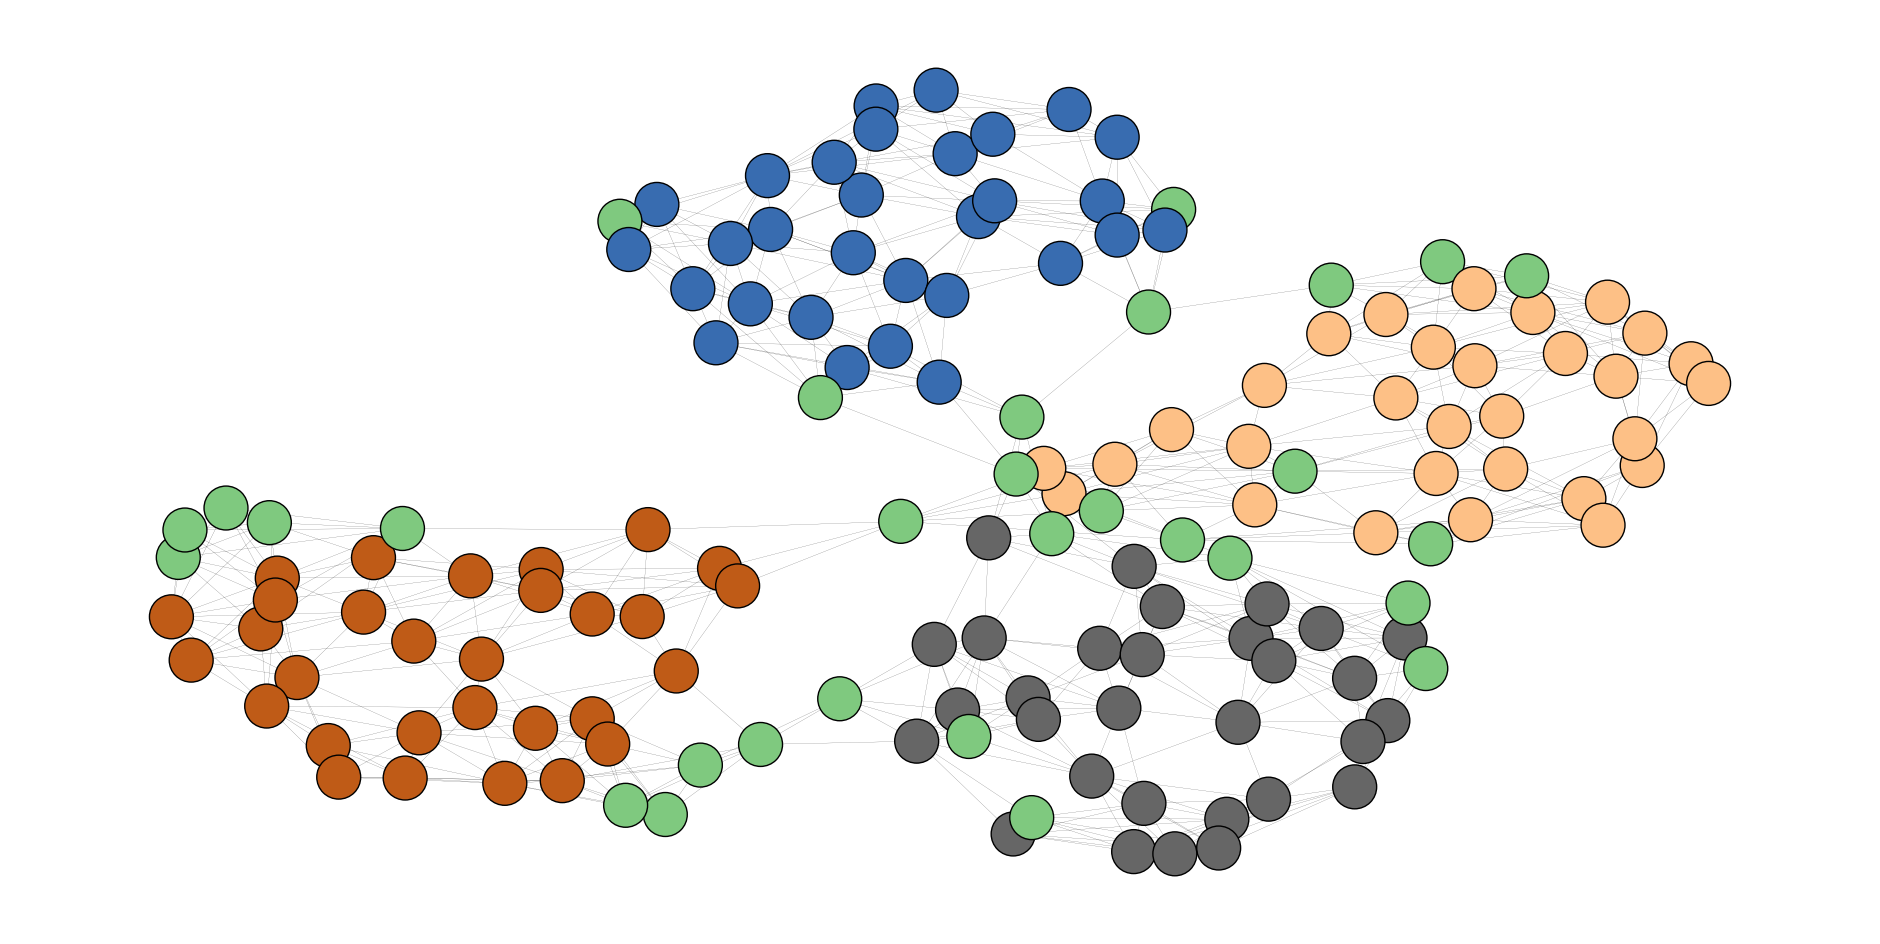

In [23]:
render_graph(testg, path = './gaus.pdf')

In [ ]:
from tqdm.auto import tqdm
from src.vcbases import retrieve_interval_bases
from src.utils import relabel_nodes_id
import numpy as np
from collections import defaultdict

time_temp = time.time()

epochs = 1

corner_points_list = [40,80,160]
sigma_center_list = [1.25, 1.75]
n_neigh_list = [5,7]
#epsilon_list = [.125,.25,.5,.625,.75,1.0]

input_list = []
for c in corner_points_list:
    for s in sigma_center_list:
        for n in n_neigh_list:
            input_list.append((c, 3*c, .2, s, n))
        #for e in epsilon_list:
        #    input_list.append((c, 4*c, .2, s, e))

seed_list = random.choices(list(range(1000)),k = 15)

rows_df = []
rows_names = []
plt_np_arr = {
    input_el : dict() for input_el,_ in enumerate(input_list)
}

for ind,(n_corner, n_center, sigma_corner, sigma_center, n_neigh) in tqdm(enumerate(input_list), total=len(input_list), desc="Retrieving and training..."):
    # FIX GRAPH for each run
    testg,_ = create_gaussian_graph(n_corner, n_center, sigma_corner, sigma_center, n_neighbors=n_neigh, seed = 42)
    largest_cc = max(nx.connected_components(testg), key=len)
    testg = testg.subgraph(largest_cc)
    testg = relabel_nodes_id(testg)
    # Retrieving balls
    balls = BallDistances(testg, initialize_sp=False, initialize_edp=False, initialize_pinv=False, disable = True)
    tolerance = 0.001
    d1_bases, n2b_d1 = retrieve_ball_bases(testg, balls.d1_ball_distance, disable=True)
    d2_bases, n2b_d2 = retrieve_ball_bases(testg, balls.d2_ball_distance, disable=True, log_balls = True)
    dinf_bases, n2b_dinf = retrieve_ball_bases(testg, balls.dinf_ball_distance, disable=True)
    lvc_bases, n2b_lvc = retrieve_lvc_bases_peeling(testg,disable=True)
    int_bases, n2b_int = retrieve_interval_bases(testg, disable = True)
    
    bases_list = [(d1_bases, n2b_d1, "D1"), 
                  (d2_bases, n2b_d2, "D2"), 
                  (dinf_bases, n2b_dinf, "D-INF"), 
                  (lvc_bases, n2b_lvc, "LVC"), 
                  (int_bases, n2b_int, "INT")]
    
    
    T = len(testg.nodes) * 20
    print(T)
    K_classes = 4
    res_list = defaultdict(lambda : [])
    res_plot = defaultdict(lambda : [])
    
    for seed in tqdm(seed_list, desc="Epochs"):    
        ##############################################################################
        ######################### TRAINING ###########################################
        ##############################################################################
        loss_perc = 0.8
        verbose = False
        for base, n2b, name in bases_list:
            res, _ = train_bandit(testg, 
                base,
                n2b,
                T,
                K_classes,
                loss_percentage = loss_perc,
                seed = seed,
                verbose = verbose,
                name=name,
                disable_tqdm_train = True, debug = True)
            res_list[name] += [res[0]/T]
            res_plot[name] += [np.array(res[1])]
            
        res_gaba, _ = train_gaba(
            testg, 
            T, 
            K_classes + 1, 
            eta = 0.5,
            seed = seed, 
            loss_percentage = loss_perc,
            debug = True, disable_tqdm_train = True, verbose = verbose)
        res_list["GABA"] += [res_gaba[0]/T]
        res_plot["GABA"] += [np.array(res_gaba[1])]
        
        res_cbs, _ = train_cont(
            testg, 
            T, 
            K_classes + 1, 
            seed = seed, 
            loss_percentage = loss_perc,
            debug = True, disable_tqdm_train = True, verbose = verbose)
        res_list["CBSim"] += [res_cbs[0]/T]
        res_plot["CBSim"] += [np.array(res_cbs[1])]
        
        res_exp3, _ = train_exp3(
            testg, 
            T, 
            K_classes + 1, 
            seed = seed, 
            loss_percentage = loss_perc,
            debug = True, verbose = verbose, disable_tqdm_train = True)
        res_list["EXP3"] += [res_exp3[0]/T]
        res_plot["EXP3"] += [np.array(res_exp3[1])]

    rate_list = [np.mean(r_l) for _,r_l in res_list.items()]
    std_list = [np.std(r_l) for _,r_l in res_list.items()]
    
    for lab, plot in res_plot.items(): 
        plt_np_arr[ind][lab] = plot
    
    rows_df += [rate_list]
    rows_names += [f'Mean{input_list[ind]}']
    rows_df += [std_list]
    rows_names += [f'Std{input_list[ind]}']

# Pandas dataframe res:
base_model_names = res_list.keys()

res_df = pd.DataFrame(columns=base_model_names)
for ind,row in enumerate(rows_df):
    res_df.loc[ind] = row
    
res_df.index = rows_names    
#res_df.to_csv(f"{save_path_name}.csv", index=True)
#f.close()
time_temp = time.time() - time_temp

Retrieving and training...:   0%|          | 0/12 [00:00<?, ?it/s]

5600


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

5600


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

...

Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

22400


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

22400


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

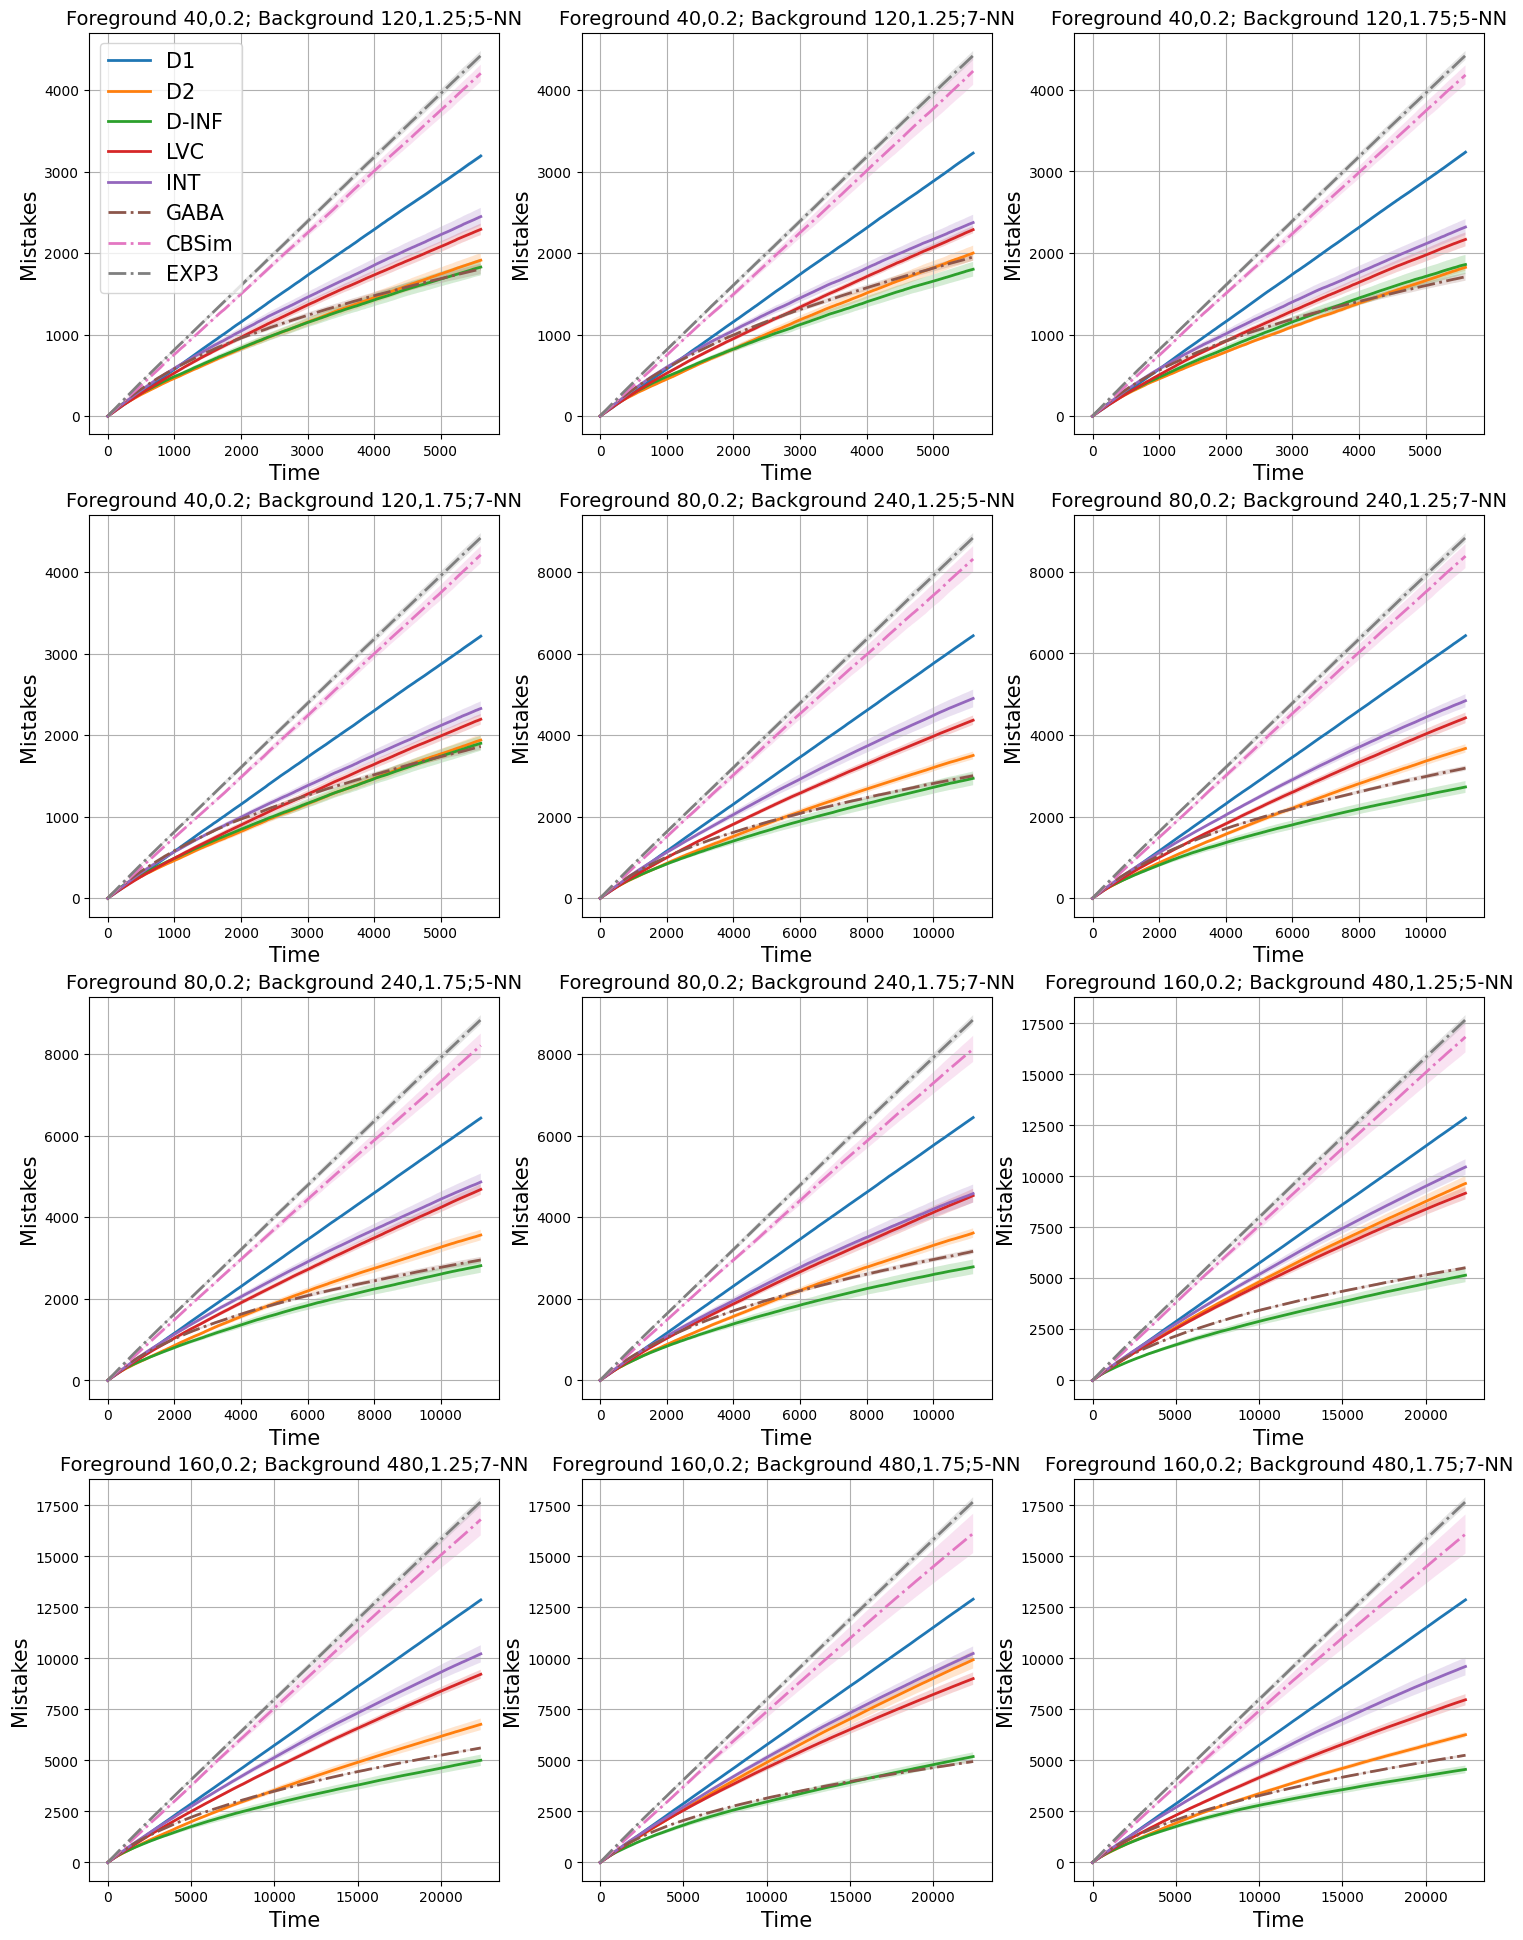

In [52]:
from src.utils import render_plot_CI

test_loaded_plot = (input_list, plt_np_arr)

render_plot_CI('Gaussian', test_loaded_plot,4,3, figx=18, figy=24, save_fig=True, path = 'results/gaussian/all_runs_gaus.svg')

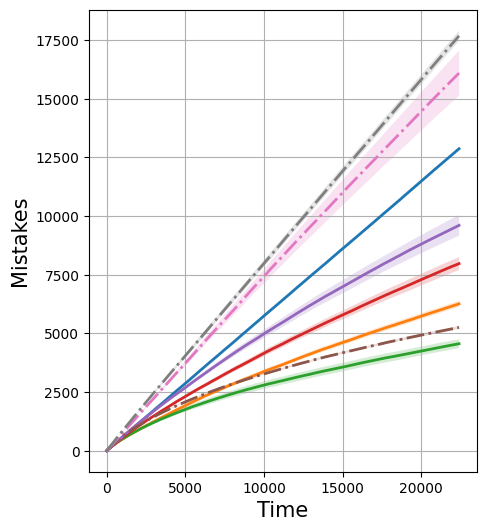

In [50]:
cora = plt_np_arr[11]

baselines = ['EXP3', 'GABA', 'CBSim']

fig, axs = plt.subplots(1, 1, figsize=(5, 6))
for sub_key, sub_data in cora.items():
    if sub_key in baselines:
        line =  'dashdot'
    else:
        line = 'solid'
    plot_data = np.mean(sub_data, axis = 0)
    axs.plot(plot_data, label=sub_key, linestyle = line, lw = 2)

    conf_int = np.std(sub_data, axis = 0) / np.sqrt(len(sub_data)) * 1.96
    axs.fill_between(np.arange(len(plot_data)), plot_data - conf_int, plot_data + conf_int, alpha=0.2)
plt.grid()
plt.xlabel('Time',fontsize=15)
plt.ylabel('Mistakes',fontsize=15) 
#plt.legend(loc=2, fontsize=15)
fig.savefig("results/gaussian_main_CI.svg", format='svg')